<a href="https://colab.research.google.com/github/chiamakachijioke/urban-mobility-optimisation/blob/main/notebooks/02_Graph_Theory_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Theory Basics for a Transport Network

This notebook represents a small transport network as a weighted graph.

The locations are represented as nodes, the available roads are represented as edges, and the road distances are represented as edge weights.

This graph will later be used to implement Dijkstra's and A* algorithms.

In [ ]:
# Import the necessary libraries
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

Note:
NetworkX is used to:

- create graphs;
- add nodes and edges;
- inspect graph structures;
- visualise graphs;
- apply graph algorithms.

For now, I will use it mainly for visualisation and checking my work. I will still create the graph structure myself.

In [ ]:
# Recreate the location data

locations = {
    0: {"name": "Depot", "x": 50, "y": 50, "demand": 0},
    1: {"name": "Customer 1", "x": 20, "y": 30, "demand": 4},
    2: {"name": "Customer 2", "x": 80, "y": 25, "demand": 6},
    3: {"name": "Customer 3", "x": 15, "y": 75, "demand": 3},
    4: {"name": "Customer 4", "x": 65, "y": 80, "demand": 7},
    5: {"name": "Customer 5", "x": 40, "y": 20, "demand": 5},
    6: {"name": "Customer 6", "x": 90, "y": 60, "demand": 4},
    7: {"name": "Customer 7", "x": 30, "y": 90, "demand": 6},
    8: {"name": "Customer 8", "x": 70, "y": 45, "demand": 2},
    9: {"name": "Customer 9", "x": 45, "y": 70, "demand": 5},
}

In [ ]:
# Recreate the distance function
# This is the straight-line distance between two locations.

def euclidean_distance(node_a, node_b, location_data):
    x1 = location_data[node_a]["x"]
    y1 = location_data[node_a]["y"]

    x2 = location_data[node_b]["x"]
    y2 = location_data[node_b]["y"]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return round(distance, 2)

## Locations are not the same as roads

The location data tell us where each node is positioned.

However, two locations should only be considered directly connected when a road or edge exists between them.

Therefore, coordinates define the positions of the nodes, while the edge list defines which direct journeys are allowed.

In [ ]:
# Create the road connections
# Each tuple represents one direct road.

connections = [
    (0, 1),
    (0, 8),
    (0, 9),

    (1, 3),
    (1, 5),

    (2, 5),
    (2, 6),
    (2, 8),

    (3, 7),
    (3, 9),

    (4, 6),
    (4, 7),
    (4, 8),
    (4, 9),

    (6, 8),

    (7, 9),

    (8, 9),
]

In [ ]:
# Count the nodes and edges

number_of_nodes = len(locations)
number_of_edges = len(connections)

print("Number of nodes:", number_of_nodes)
print("Number of edges:", number_of_edges)

Number of nodes: 10
Number of edges: 17


Note:
    
    A node is a location.
    An edge is a direct road.

In [ ]:
# Build an adjacency list
# An adjacency list stores the neighbours of every node.

graph = {
    node: {}
    for node in locations
}

# At this point, it creates:

{
    **0: {},**
    **1: {},**
    **2: {},**
    **3: {},**
    **4: {},**
    **5: {},**
    **6: {},**
    **7: {},**
    **8: {},**
    **9: {}**
}

In [ ]:
# Every node exists, but no neighbours have been added yet.
# Now to add the roads:

for node_a, node_b in connections:
    road_distance = euclidean_distance(
        node_a,
        node_b,
        locations
    )

    graph[node_a][node_b] = road_distance
    graph[node_b][node_a] = road_distance

In [ ]:
graph

{0: {1: 36.06, 8: 20.62, 9: 20.62},
 1: {0: 36.06, 3: 45.28, 5: 22.36},
 2: {5: 40.31, 6: 36.4, 8: 22.36},
 3: {1: 45.28, 7: 21.21, 9: 30.41},
 4: {6: 32.02, 7: 36.4, 8: 35.36, 9: 22.36},
 5: {1: 22.36, 2: 40.31},
 6: {2: 36.4, 4: 32.02, 8: 25.0},
 7: {3: 21.21, 4: 36.4, 9: 25.0},
 8: {0: 20.62, 2: 22.36, 4: 35.36, 6: 25.0, 9: 35.36},
 9: {0: 20.62, 3: 30.41, 4: 22.36, 7: 25.0, 8: 35.36}}

    graph[node_a][node_b] = road_distance

adds the road from node_a to node_b.

Therefore, this is an **undirected graph**.

The road can be used both ways.

**Interpreting:**

It means node 0 has three neighbours:

    node 1, with road distance 36.06;
    node 8, with road distance 20.62;
    node 9, with road distance 20.62.

This means these are the only nodes that can be reached directly from node 0.

## My understanding

The adjacency list shows which nodes are directly connected.

The outer dictionary key represents the current node. The inner dictionary keys represent its neighbours, while the values represent the road distances.

In [ ]:
# Create a function to return neighbours

def get_neighbours(node, graph_data):
    if node not in graph_data:
        raise ValueError(f"Node {node} does not exist.")

    return graph_data[node]

In [ ]:
# Testing:

node_0_neighbours = get_neighbours(0, graph)

print("Neighbours of node 0:")
print(node_0_neighbours)

Neighbours of node 0:
{1: 36.06, 8: 20.62, 9: 20.62}


In [ ]:
# Check whether two nodes are directly connected

def edge_exists(node_a, node_b, graph_data):
    return (
        node_a in graph_data
        and node_b in graph_data[node_a]
    )

In [ ]:
# Testing:

print(
    "Is there a direct edge from 0 to 8?",
    edge_exists(0, 8, graph)
)

print(
    "Is there a direct edge from 0 to 2?",
    edge_exists(0, 2, graph)
)

Is there a direct edge from 0 to 8? True
Is there a direct edge from 0 to 2? False


This does not mean node 2 is unreachable from node 0.

It only means there is no direct edge between them.

# **Edge weight**

In [ ]:
# Get an edge weight

def get_edge_weight(node_a, node_b, graph_data):
    if not edge_exists(node_a, node_b, graph_data):
        raise ValueError(
            f"No direct edge exists between "
            f"node {node_a} and node {node_b}."
        )

    return graph_data[node_a][node_b]

In [ ]:
# Testing:

weight_0_to_8 = get_edge_weight(0, 8, graph)

print(
    "Weight of edge 0 → 8:",
    weight_0_to_8
)

Weight of edge 0 → 8: 20.62


# **Path**

A path is a sequence of nodes where every consecutive pair is connected by an edge.

**For example,**

    [0, 8, 2, 6] is a valid path because
    
    the edges 0–8, 8–2, and 2–6 all exist.

A path is not necessarily the shortest path.

It is simply one valid way of travelling between locations.

In [ ]:
# Check whether a path is valid

def is_valid_path(path, graph_data):
    if len(path) < 2:
        return False

    for index in range(len(path) - 1):
        current_node = path[index]
        next_node = path[index + 1]

        if not edge_exists(
            current_node,
            next_node,
            graph_data
        ):
            return False

    return True

In [ ]:
# Testing:

valid_path = [0, 8, 2, 6]
invalid_path = [0, 2, 6]

print(
    valid_path,
    "is valid:",
    is_valid_path(valid_path, graph)
)

print(
    invalid_path,
    "is valid:",
    is_valid_path(invalid_path, graph)
)

[0, 8, 2, 6] is valid: True
[0, 2, 6] is valid: False


# **path cost**

In [ ]:
# Calculate a path cost

def calculate_path_cost(path, graph_data):
    if not is_valid_path(path, graph_data):
        raise ValueError(
            f"{path} is not a valid path."
        )

    total_cost = 0

    for index in range(len(path) - 1):
        current_node = path[index]
        next_node = path[index + 1]

        edge_weight = graph_data[current_node][next_node]
        total_cost += edge_weight

    return round(total_cost, 2)

In [ ]:
# Testing:

example_path = [0, 8, 2, 6]

path_cost = calculate_path_cost(
    example_path,
    graph
)

print("Path:", example_path)
print("Path cost:", path_cost)

Path: [0, 8, 2, 6]
Path cost: 79.38


# Compare two valid paths

In [ ]:
# Compare two valid paths

path_1 = [1, 0, 8, 6]
path_2 = [1, 5, 2, 6]

cost_1 = calculate_path_cost(path_1, graph)
cost_2 = calculate_path_cost(path_2, graph)

print("Path 1:", path_1)
print("Cost of Path 1:", cost_1)

print()

print("Path 2:", path_2)
print("Cost of Path 2:", cost_2)

Path 1: [1, 0, 8, 6]
Cost of Path 1: 81.68

Path 2: [1, 5, 2, 6]
Cost of Path 2: 99.07


Basically, I am comparing two possible journeys from

    node 1 to node 6.

I am doing this manually.

Dijkstra will later search systematically and determine the cheapest possible path automatically.

# **NetworkX graph**

Now I will use NetworkX to visualise the same graph.

nx.Graph() creates an undirected graph.

In [ ]:
# Create the NetworkX graph

transport_graph = nx.Graph()

In [ ]:
# Add the nodes

for node, data in locations.items():
    transport_graph.add_node(
        node,
        name=data["name"],
        demand=data["demand"],
        pos=(data["x"], data["y"])
    )

In [ ]:
# Add the Edges

for node_a, node_b in connections:
    road_distance = euclidean_distance(
        node_a,
        node_b,
        locations
    )

    transport_graph.add_edge(
        node_a,
        node_b,
        weight=road_distance
    )

Now NetworkX contains the same graph as my adjacency-list dictionary.

In [ ]:
# Inspect the NetworkX graph

print(
    "Nodes:",
    list(transport_graph.nodes)
)

print(
    "Edges:",
    list(transport_graph.edges)
)

print(
    "Number of nodes:",
    transport_graph.number_of_nodes()
)

print(
    "Number of edges:",
    transport_graph.number_of_edges()
)

Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Edges: [(0, 1), (0, 8), (0, 9), (1, 3), (1, 5), (2, 5), (2, 6), (2, 8), (3, 7), (3, 9), (4, 6), (4, 7), (4, 8), (4, 9), (6, 8), (7, 9), (8, 9)]
Number of nodes: 10
Number of edges: 17


In [ ]:
# Visualise the graph
# This tells NetworkX where each node should appear.

positions = {
    node: (
        data["x"],
        data["y"]
    )
    for node, data in locations.items()
}

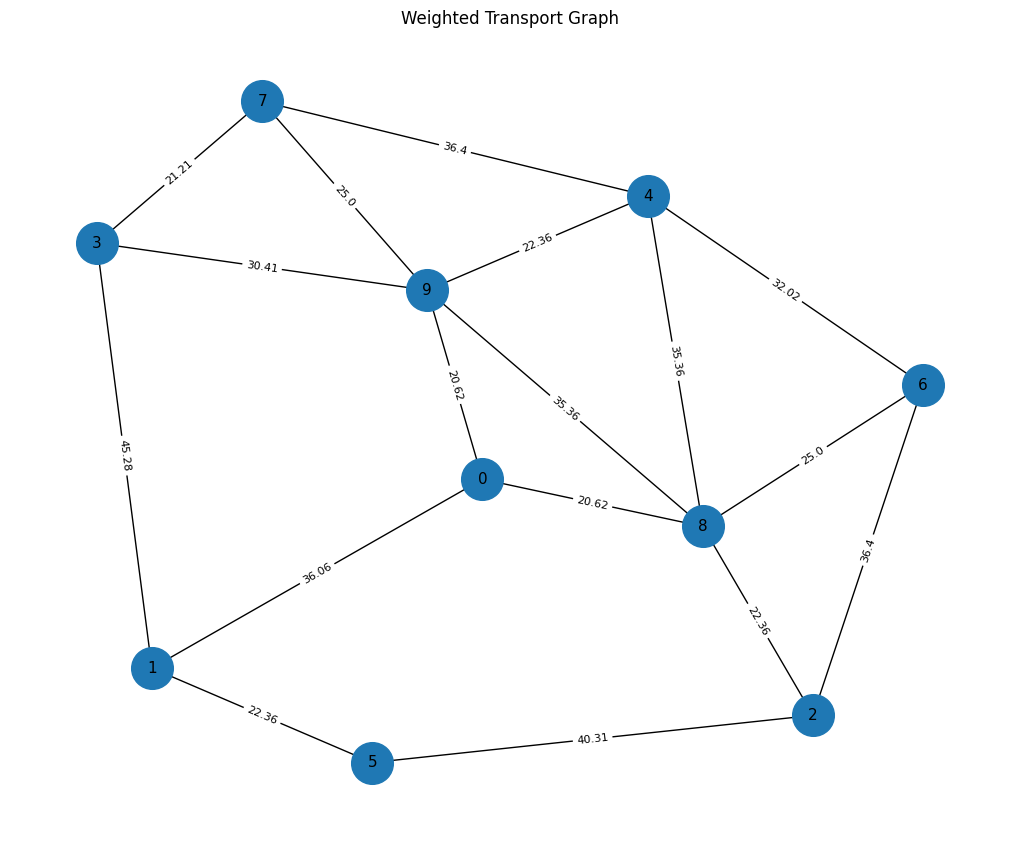

In [ ]:
# Plotting:

plt.figure(figsize=(10, 8))

nx.draw(
    transport_graph,
    pos=positions,
    with_labels=True,
    node_size=900,
    font_size=11
)

edge_labels = nx.get_edge_attributes(
    transport_graph,
    "weight"
)

nx.draw_networkx_edge_labels(
    transport_graph,
    pos=positions,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Weighted Transport Graph")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.show()

# **Degree of each node**

The degree of a node is the number of edges connected to it.

A node with many connections has a high degree.

A node with few connections has a low degree.

In [ ]:
# Find the degree of each node

for node in transport_graph.nodes:
    degree = transport_graph.degree[node]

    print(
        f"Node {node} has degree {degree}"
    )

Node 0 has degree 3
Node 1 has degree 3
Node 2 has degree 3
Node 3 has degree 3
Node 4 has degree 4
Node 5 has degree 2
Node 6 has degree 3
Node 7 has degree 3
Node 8 has degree 5
Node 9 has degree 5


# **Connected graph**

A connected graph means every node can be reached from every other node through some path.

In [ ]:
# Check whether the graph is connected

connected = nx.is_connected(transport_graph)

print(
    "Is the graph connected?",
    connected
)

Is the graph connected? True


## **Cycle**

A cycle is a valid path that begins and ends at the same node.

For example, [0, 1, 5, 2, 8, 0] is a cycle because it begins at node 0, follows valid edges, and returns to node 0.

Cycles are important in vehicle routing because vehicles commonly leave the depot, visit customers, and return to the depot.

In [ ]:
# Check if a cycle is a valid path

example_cycle = [0, 1, 5, 2, 8, 0]

print(
    "Is the cycle a valid path?",
    is_valid_path(example_cycle, graph)
)

print(
    "Cycle cost:",
    calculate_path_cost(example_cycle, graph)
)

Is the cycle a valid path? True
Cycle cost: 141.71


# **Sparse graph and complete graph**

A sparse graph has relatively few edges compared with the number of possible edges.

A complete graph connects every pair of nodes directly.

The current transport graph is sparse because only selected road connections exist.

In [ ]:
# Compare a sparse and complete graph
# For ten nodes, the maximum number of undirected edges is:

maximum_edges = (
    number_of_nodes
    * (number_of_nodes - 1)
    // 2
)

print(
    "Maximum possible edges:",
    maximum_edges
)

print(
    "Current number of edges:",
    number_of_edges
)

Maximum possible edges: 45
Current number of edges: 17


# **FINAL NOTES**

# What I learned

- A graph consists of nodes and edges.
- Each transport location is represented as a node.
- Each available road is represented as an edge.
- An edge weight represents the cost of using a road.
- In this notebook, the edge weight is the Euclidean distance.
- An adjacency list records the neighbours and edge weights of every node.
- A path is a valid sequence of connected nodes.
- A path cost is the sum of its edge weights.
- A cycle begins and ends at the same node.
- The graph is undirected because every road can be used in both directions.
- The graph is weighted because every road has a distance.
- The graph is sparse because not every pair of nodes is directly connected.
- The graph is connected because every node can be reached from every other node through some path.